In [2]:
import sys
import os
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Verdana', 'Lucida Grande', 'DejaVu Sans']

from lmfit import Model, Minimizer, Parameters, fit_report, report_fit # Import lmfit components needed for fitting

# Import the main processor class and necessary helper functions

from importlib import reload

import bbdata_processing_utils
reload(bbdata_processing_utils)

try:
    from bbdata_processing_utils import BBProcessor
    print("Successfully imported BBProcessor and helpers.")
except ImportError as e:
    print(f"ERROR: {e}")
    # Stop execution if import fails
    raise e


Successfully imported BBProcessor and helpers.


In [3]:
basepath = '/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/dm'
chime_dm_json = 'chime_dm_params.json'

In [4]:
names = np.array([
#'zach',
#'whitney',
#'oran',
#'isha',
#'wilhelm',
#'phineas',
#'freya',
#'johndoeII',
'hamilton',
#'mahi',
#'chromatica',
#'casey',
])

dmtransform_chime = np.array([
262.368,
462.174,
396.882,
411.568,
602.346,
610.274,
912.400,
696.506,
518.799,
960.128,
272.664,
491.207
])

with open(os.path.join(basepath, chime_dm_json), 'r') as file:
    chime_dm_fits = json.load(file)
    
dmphase_chime = np.zeros_like(dmtransform_chime)

for i in range(names.shape[0]):
    dmphase_chime[i] = dmtransform_chime[i] + chime_dm_fits[names[i]]['dm_offset']
    
print(dmphase_chime)

[262.36210158 462.18910384 397.01530917 411.43587672 602.38087534
 610.28939423 912.40669107 696.51841744 518.80071413 960.13157852
 272.63816988 491.20849451]


In [5]:
# == Event Selection & Data ==
chimeids = np.array([
'210456524',
'215063905',
'224263996',
'252069198',
'253635173',
'274819243',
'278720455',
'311723353',
'318353610',
'354049284',
'356959136',
'362593221'
])

dir_paths = np.array([
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/03/10/astro_215063905/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/05/06/astro_224263996/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/11/13/astro_252069198/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/12/03/astro_253635173/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/07/astro_274819243',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/25/astro_278720455',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/08/14/astro_311723353',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/01/22/astro_354049284',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/03/astro_356959136',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/29/astro_362593221'
])

file_paths = np.array([
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/03/10/astro_215063905/run_pre_apr2025/singlebeam_215063905.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/05/06/astro_224263996/run_pre_apr2025/singlebeam_224263996.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/11/13/astro_252069198/run_pre_apr2025/singlebeam_252069198.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/12/03/astro_253635173/run_pre_apr2025/singlebeam_253635173.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/07/astro_274819243/singlebeam_274819243.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/25/astro_278720455/singlebeam_278720455.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/08/14/astro_311723353/singlebeam_311723353.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610/singlebeam_318353610.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/01/22/astro_354049284/singlebeam_354049284.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/03/astro_356959136/singlebeam_356959136.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/29/astro_362593221/singlebeam_362593221.h5'
])

#names = ['zach']
#chimeids = [210456524]
#dms_opt = [262.368]
#file_paths = ['/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5'] # Use None to trigger auto-path finding if API works

# Select the event index to process
#event_idx = 0
for event_idx in range(len(chimeids)):
    NAME = names[event_idx]
    EVENT_ID = chimeids[event_idx]
    DM_VALUE = round(dmphase_chime[event_idx], 4) #dmtransform_chime[event_idx]
    BASEBAND_FILE_PATH = file_paths[event_idx] # Use None if path is not known
    EVENT_NAME_STR = names[event_idx] # For output filenames

    # == Output Directory ==
    # Create a unique directory for this event's plots
    DIAGNOSTIC_PLOTS_DIR = f"./processed_waterfalls" # Use event name

    # == Pipeline Parameters ==
    # Preprocessing
    DOWNFREQ = 1
    SPEC_LIMS = (0, 1023) #None # Or e.g., [100, 900]
    ZAP_EXTRA_RFI = True # Assuming default unless specified otherwise

    print(f"--- Parameters for Event: {EVENT_NAME_STR} (ID: {EVENT_ID}) ---")
    print(f"DM: {DM_VALUE}")
    print(f"Baseband File: {BASEBAND_FILE_PATH if BASEBAND_FILE_PATH else 'Auto-detect'}")
    print(f"Output Directory: {DIAGNOSTIC_PLOTS_DIR}")
    print("------------------------------------------------")
    
    # Create output directory
    #if DIAGNOSTIC_PLOTS_DIR:
    #    os.makedirs(DIAGNOSTIC_PLOTS_DIR, exist_ok=True)
    #    print(f"Ensured output directory exists: {DIAGNOSTIC_PLOTS_DIR}")

    # Instantiate the processor
    try:
        processor = BBProcessor(
            event_id=EVENT_ID,
            dm=DM_VALUE,
            baseband_file=BASEBAND_FILE_PATH,
            output_dir=DIAGNOSTIC_PLOTS_DIR # Pass the specific dir
        )
        print("BBProcessor initialized.")
    except Exception as e:
        print(f"ERROR: Failed to initialize BBProcessor: {e}")
        raise e

    # Run the main pipeline

    I_proc, prof_nat, lims_env, dur = processor.run_full_pipeline(
        downfreq=DOWNFREQ,
        interactive_time=True,
        zap_extra=ZAP_EXTRA_RFI,
        spec_lims=SPEC_LIMS
    )
    
    DM_STR = str(round(DM_VALUE, 4))
    print(f'DM String: {DM_STR}')
    
    np.save(f"/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/CHIME_bursts/dmphase/{NAME}_I_{DM_STR.split('.')[0]}_{DM_STR.split('.')[1]}_{I_proc.shape[1]}b_longer", I_proc.filled(np.nan))


--- Parameters for Event: zach (ID: 210456524) ---
DM: 262.3621
Baseband File: /arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5
Output Directory: ./processed_waterfalls
------------------------------------------------
Successfully connected and authorized CHIME FRB Master API.
Initialized BBProcessor for Event 210456524, DM 262.3621
BBProcessor initialized.

=== Running Preprocessing Pipeline for Event 210456524 ===
Using provided baseband file: /arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5
Loading BBData from: /arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5



KeyboardInterrupt



In [18]:
from baseband_analysis.core.signal import get_main_peak_lim, tiedbeam_baseband_to_power, get_spectrum_lim
from baseband_analysis.core.bbdata import BBData
from baseband_analysis.analysis.snr import get_snr, get_profile
from baseband_analysis.core.sampling import scrunch
from baseband_analysis.core.dedispersion import coherent_dedisp, incoherent_dedisp, get_freq # Keep both for potential future use/reference
from baseband_analysis.analysis.polarization import get_burst_envelope
from chime_frb_constants import FPGA_DELTA_FREQ_MHZ, K_DM

In [19]:
incoherent_dedisp?

Signature:
incoherent_dedisp(
    data,
    DM,
    factor=1,
    matrix_in=None,
    downsampled_time=1,
    fill_wfall=True,
    freq=None,
    f_ref=None,
    t_ref=None,
)
Docstring:
Apply incoherent dedispersion.

Parameters
----------
data: `BBData`
    Data to dedisperse.
DM: float
    DM to apply for dedispersion.
factor: int, default 1
   Time downsampling factor.
matrix_in: `ndarray`
    Defaults to tiedbeam_baseband data.
downsampled_time: int
fill_wfall: bool
    If True, fill the waterfall with zeros for non-selected frequencies.
    Default True.
freq: tuple (int or float, float)
    Frequency channel and frequency.

Returns
-------
ndarray of complex128:
    Waterfall data.
float:
    Frequency
int:
    Frequency channel id.
File:      /opt/pysetup/baseband_analysis/core/dedispersion.py
Type:      function

In [42]:
def delay_across_the_band(
    DM: float, freq_low: float = 400.390625, freq_high: float = 800
) -> float:
    """
    Return the delay in seconds caused by dispersion.

    It is assumed that Dispersion Measure (DM) in cm-3 pc, and the emitted
    frequency (freq_emitted) of the pulsar in MHz.

    Parameters
    ----------
    DM : float
        Dispersion measure.
    freq_low : float, optional
        Lowest observing frequency in MHz, by default 400
    freq_high : float, optional
        Highest observing frequency in MHz, by default 800

    Returns
    -------
    float
        Delay across the band.
    """
    return K_DM * DM * (1.0 / freq_low**2 - 1.0 / freq_high**2)

def incoherent_dedisp(
    data,
    DM,
    factor=1,
    fill_wfall_no=1,
    matrix_in=None,
    downsampled_time=1,
    fill_wfall=True,
    freq=None,
    f_ref=None,
    t_ref=None,
):
    """
    Apply incoherent dedispersion.

    Parameters
    ----------
    data: `BBData`
        Data to dedisperse.
    DM: float
        DM to apply for dedispersion.
    factor: int, default 1
       Time downsampling factor.
    matrix_in: `ndarray`
        Defaults to tiedbeam_baseband data.
    downsampled_time: int
    fill_wfall: bool
        If True, fill the waterfall with zeros for non-selected frequencies.
        Default True.
    freq: tuple (int or float, float)
        Frequency channel and frequency.

    Returns
    -------
    ndarray of complex128:
        Waterfall data.
    float:
        Frequency
    int:
        Frequency channel id.

    """
    if matrix_in is None:
        matrix_in = data["tiedbeam_baseband"][:]
    matrix_in = matrix_in.copy()
    wfall = np.zeros_like(matrix_in)

    if freq is None:
        f_id, f = get_freq(data, factor=factor)
    else:
        f_id, f = freq
    if f_ref is None:
        f_ref = min(f)
    f_id_ref = f_id[f_ref == f]

    if t_ref is None:
        t_ref = (
            data["time0"]["ctime"][f_id_ref == f_id]
            + data["time0"]["ctime_offset"][f_id_ref == f_id]
        )

    dt = data.attrs["delta_time"] * downsampled_time

    for i in range(matrix_in.shape[0]):
        j = i // factor
        t_shift = data["time0"]["ctime"][j] + data["time0"]["ctime_offset"][j] - t_ref
        start_t = t_shift + delay_across_the_band(DM, f_ref, f[i])
        bins_shift = np.round(start_t / dt / factor).astype(int)
        wfall[i] = np.roll(matrix_in[i], bins_shift, axis=-1)

    if fill_wfall:
        wfall_filled = np.zeros(
            (f_id.max() + fill_wfall_no,) + (wfall.shape[1], wfall.shape[2]), dtype=wfall.dtype
        )
        wfall_filled[f_id] = wfall
        return wfall_filled, f, f_id
    else:
        return wfall, f, f_id

bbdata = BBData.from_file('/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610/singlebeam_318353610.h5')
DM = 518.799
bb = coherent_dedisp(bbdata, DM, time_shift = False)
# Reset baseband data to coherently dedispersed
bbdata["tiedbeam_baseband"][:] = bb 
# Incoherently dedisperse
bb, freq, freq_id = incoherent_dedisp(bbdata, DM, fill_wfall_no=2, fill_wfall=True)
# Calculate power by summing together polarizations in quadrature
power_filled = np.abs(bb[:, 0, :]) ** 2 + np.abs(bb[:, 1, :]) ** 2

518.799 518.799 0


In [43]:
power_filled_bpc = power_filled.copy()

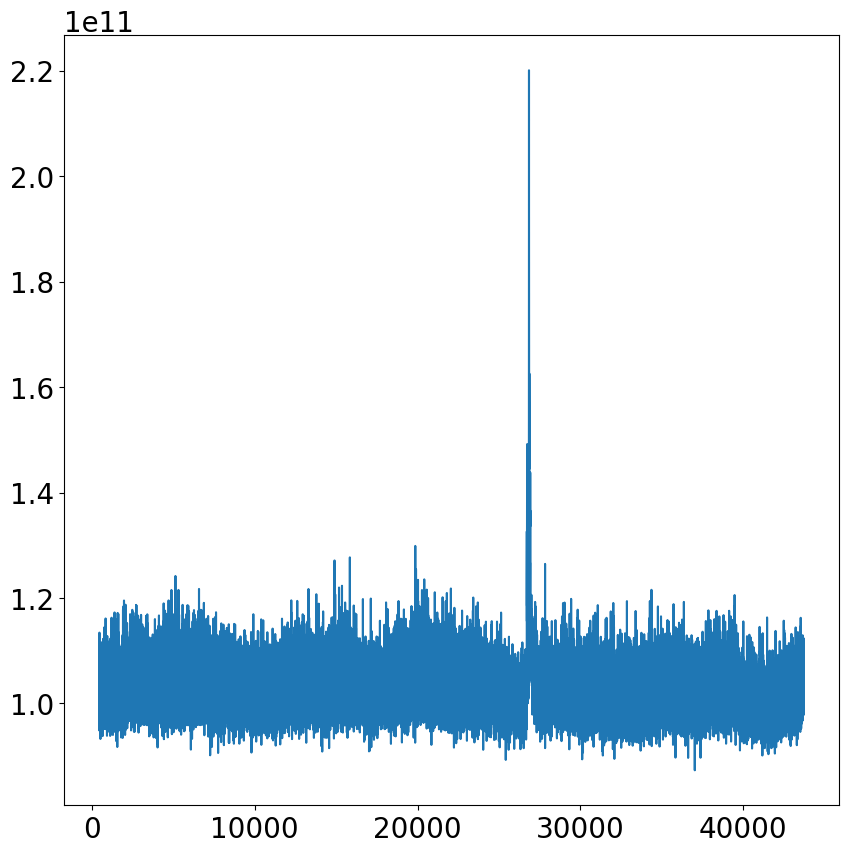

In [44]:
plt.plot(power_filled_bpc.sum(0))

In [45]:
spec = np.nansum(power_filled_bpc,axis=1)
spec /= np.max(spec)
power_filled_bpc[spec>0.2] = 0


In [47]:
for c in range(1024):
    power_filled_bpc[c, :] -= np.nanmean(power_filled[c, 10000:20000])
    power_filled_bpc[c, :] /= np.nanstd(power_filled[c, 10000:20000])

In [53]:
spec_bpc = np.nansum(power_filled_bpc,axis=1)
spec_bpc /= np.max(spec_bpc)
power_filled_bpc[spec_bpc>0.2] = 0
power_filled_bpc[spec_bpc<-0.2] = 0

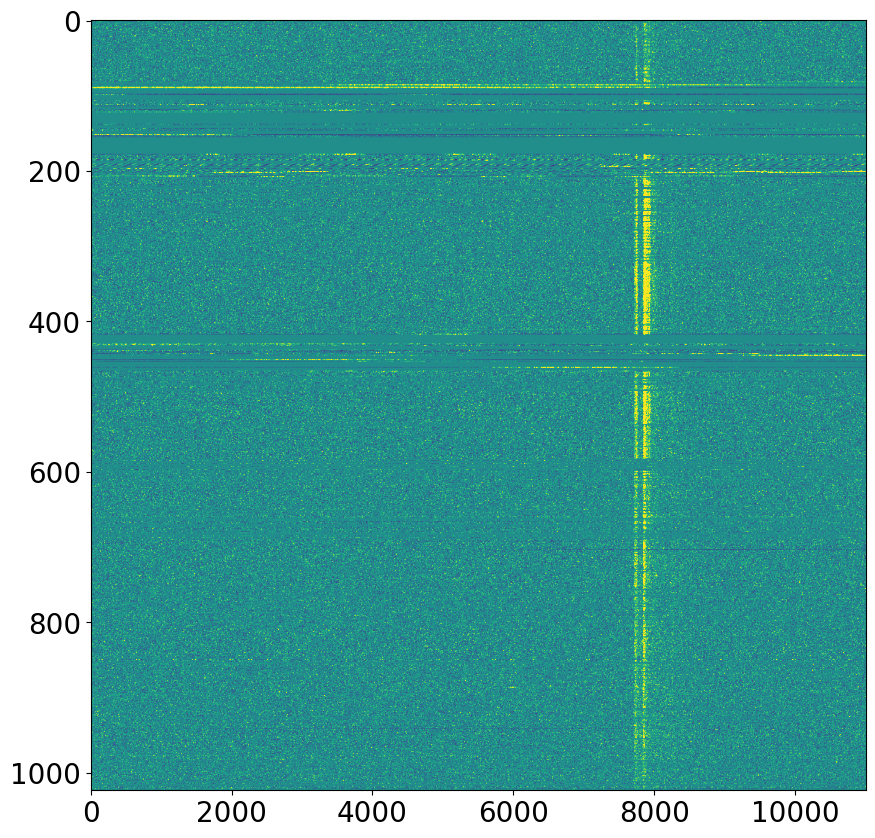

In [58]:
mean = np.nanmean(power_filled_bpc[:, 19000:30000])
std = np.nanstd(power_filled_bpc[:, 19000:30000])
plt.imshow(np.nan_to_num(power_filled_bpc[:, 19000:30000]), aspect='auto', vmin=mean-std, vmax=mean+std)

In [26]:
x = 345.654
x_str = str(x)
print(x_str.split('.')[0])
print(str(x))

345
345.654


Ensured output directory exists: ./processed_waterfalls
Successfully connected and authorized CHIME FRB Master API.
Initialized BBProcessor for Event 210456524, DM 262.368
BBProcessor initialized.

=== Running Preprocessing Pipeline for Event 210456524 ===
Using provided baseband file: /arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5
Loading BBData from: /arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5
Raw data loaded. Shape: (871, 2, 55949)

--- Starting Data Preprocessing ---
Calculating SNR (downsample=32)...


[2025-05-19 04:27:14,162] INFO Best DM found at 262.42842588940215 pc/cc


Initial valid time range (native bins): [    0 43702]
Number of initial valid channels: 663
Checking dedispersion status (Target DM=262.368)...
Applying coherent dedispersion (DM=262.368)...
262.368 262.368 0
Coherent dedispersion applied in-place to 'tiedbeam_baseband'.
Incoherent dedispersion applied.
Applying initial channel and time masks...
Data trimmed by SNR time limits to native bins: [0, 43702]
Determining analysis time window (on/off burst selection)...


/opt/pysetup/.venv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


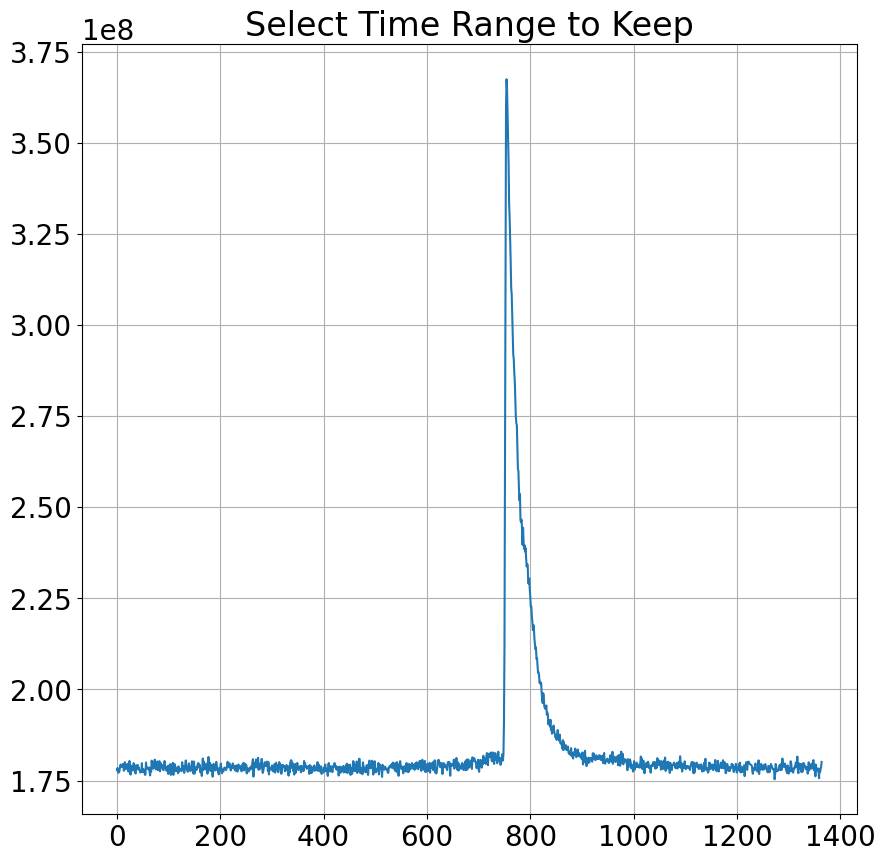

Define downsampled time bin range (e.g., '100,1265'):  400, 1200


Selected downsampled time range: [400, 1200]
Final selected native time range for analysis: [12800, 38400]
Filling missing channels to 1024...
Data sliced to final time window. Shape: (1024, 2, 25600)
Performing extra RFI zapping...
Determining frequency limits...


/opt/pysetup/.venv/lib/python3.8/site-packages/numpy/lib/function_base.py:3882: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  part.partition(kth)


Determined frequency limits (channel indices): (0, 1024)
Data sliced to frequency limits [0, 1024]. Final shape: (1024, 2, 25600)
Final frequency range: 400.20 - 800.20 MHz
Generating final time profile plot...
Saved final profile plot: ./processed_waterfalls/onburst_prof_evt210456524.png
--- Finished Data Preprocessing ---


In [3]:
# Create output directory
if DIAGNOSTIC_PLOTS_DIR:
    os.makedirs(DIAGNOSTIC_PLOTS_DIR, exist_ok=True)
    print(f"Ensured output directory exists: {DIAGNOSTIC_PLOTS_DIR}")

# Instantiate the processor
try:
    processor = BBProcessor(
        event_id=EVENT_ID,
        dm=DM_VALUE,
        baseband_file=BASEBAND_FILE_PATH,
        output_dir=DIAGNOSTIC_PLOTS_DIR # Pass the specific dir
    )
    print("BBProcessor initialized.")
except Exception as e:
    print(f"ERROR: Failed to initialize BBProcessor: {e}")
    raise e

# Run the main pipeline

I_proc, prof_nat, lims_env, dur = processor.run_full_pipeline(
    downfreq=DOWNFREQ,
    interactive_time=True, # Set to False for notebook execution
    zap_extra=ZAP_EXTRA_RFI,
    spec_lims=SPEC_LIMS,
    manual_off_burst_range_native=MANUAL_OFF_BURST_RANGE_NATIVE
)


In [5]:
print(I_proc.shape)

(1024, 25600)


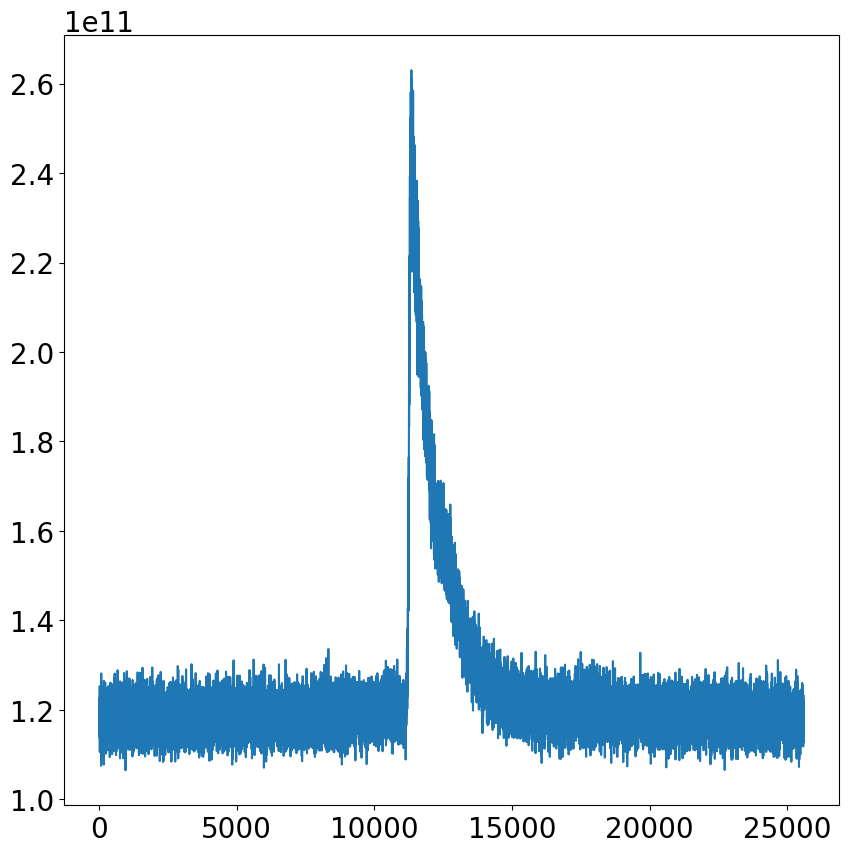

In [6]:
plt.plot(np.nansum(I_proc, axis=0))